# Applications of Phase Retrieval, and When to Trust It
## Tested against this repo's own "real" sample data

**What this notebook does.** Three things, in order: (1) a grounded survey of
where phase retrieval is actually used, beyond this project's own carrier-less
receiver; (2) a concrete "when to trust a phase-retrieval result" framework,
built directly from two real failure modes this project discovered the hard
way; (3) applying that framework to `sample_data/*.mat` -- the closest thing
this repo has to real, externally-provided data -- to answer, with evidence,
whether it actually behaves the way `dgs.gs_core` needs it to.

**Spoiler on the third point, stated up front rather than buried.** The
`sample_data/*.mat` files' own embedded `description` field reads: *"Synthetic
dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE
undergrad project."* This is not Jalali Lab data -- it is a placeholder from
an unrelated course project, and running the "when to trust it" checks built
in Section 2 against it in Section 3 shows exactly why that distinction
matters.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import glob
import pathlib

from dgs.gs_core import make_measurements, retrieve_phase, retrieve_phase_with_history
from dgs import gs_verify
from dgs.real_data_loader import (
    load_mat_measurement, diagnose_measurement, default_candidates,
    convergence_sanity_sweep,
)

print("Setup complete.")

Setup complete.


## 1. Where phase retrieval is actually used

Phase retrieval -- recovering phase from intensity-only measurements -- is a
family of algorithms, not one technique, sharing the same core problem:
a detector (camera, photodiode, CCD) only ever measures |field|^2, never
the field's phase directly. Four established application areas, cited
honestly rather than assumed:

1. **Coherent diffraction imaging (CDI) / X-ray crystallography.** The
   original motivation: Gerchberg and Saxton's 1972 algorithm (*Optik*
   35(2), 237-246) recovers a specimen's structure from its measured
   diffraction pattern, without a lens capable of focusing X-rays. This is
   the direct ancestor of every algorithm in this repo's `dgs.gs_core`.
2. **Adaptive optics / wavefront sensing.** Astronomical telescopes and
   ophthalmology instruments recover wavefront aberrations from
   intensity-only sensor readings (e.g. Shack-Hartmann-adjacent phase
   retrieval techniques) to drive deformable-mirror correction.
3. **Ultrafast pulse characterization.** FROG and SPIDER (not
   Gerchberg-Saxton-based, but solving the same class of problem) recover
   a femtosecond laser pulse's full electric field from intensity
   autocorrelation/spectral measurements.
4. **Carrier-less optical communication -- this project's own application.**
   Solli, Gupta, and Jalali's 2009 paper (*Appl. Phys. Lett.* 95, 231108)
   adapts Gerchberg-Saxton to the **time domain** via the dispersive
   Fourier transform, recovering an optical field's phase from two
   dispersed intensity-only photodiode traces -- no local oscillator, no
   coherent mixer. `dgs.gs_core.retrieve_phase` implements exactly this,
   and Section 1 of `notebooks/ousd_critical_tech_capstone.ipynb`
   demonstrates it live.

A fifth, closely related area already built out elsewhere in this repo:
**single-shot spectroscopy via the dispersive Fourier transform itself**
(not phase retrieval, but the same underlying physics) -- `dgs.time_stretch_dft`
and Section 5 of `ousd_critical_tech_capstone.ipynb`.

## 2. When to trust a phase-retrieval result

Two concrete failure modes this project found -- not textbook warnings, but
things that actually happened while building this repo -- define what
"trust" has to mean here.

### Failure mode 1: the amplitude-error metric can be near-perfect while the recovered field is wrong

Found reproducing a course presentation's gas-cell result
(`notebooks/matlab_figures_reproduced.ipynb`, Section 7): for
varying-envelope (`unit_amplitude=False`) signals, `retrieve_phase`'s own
amplitude-error metric read ~1e-14 (excellent) while the recovered field's
spectrum correlation to the known true field was only ~0.5 -- stable across
20 to 2000 iterations, so not an under-convergence issue. GS had converged,
just to the *wrong* fixed point, and the only metric the function exposes
could not tell the difference.

### Failure mode 2: below the diversity-requirement threshold, the algorithm still returns a confident-looking number

`dgs.gs_verify`'s own formal test (`S9`) already documents that `|D| >= 5000`
is needed for reliable convergence -- demonstrating live, on a case built
specifically for this notebook, how far the exposed error metric can
mislead when that threshold is violated:

In [2]:
# A deliberately weak-dispersion case: |D| well below gs_core's own recommended threshold
m_weak = make_measurements('QPSK', n_symbols=64, sps=8, D1=-20, D2=-40, snr_db=25, rng_seed=0)

import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    phi_weak, err_weak, E_hist_weak = retrieve_phase_with_history(
        m_weak['I1'], m_weak['I2'], m_weak['D1'], m_weak['D2'], n_iter=50, unit_amplitude=m_weak['unit_amplitude']
    )
    gs_core_warnings = [str(x.message) for x in w]

phase_corr_weak = np.corrcoef(np.cos(phi_weak), np.cos(m_weak['phi_true']))[0, 1]

print(f"gs_core's own warning(s) raised for this D:")
for msg in gs_core_warnings:
    print(f"  {msg}")
print(f"\nFinal amplitude error: {err_weak[-1]:.4e}   (looks fine in isolation)")
print(f"Recovered-vs-true PHASE correlation: {phase_corr_weak:.4f}   (the number that actually matters)")

gs_core's own warning(s) raised for this D:
  |D1|=20.0 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.
  |D2|=40.0 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.

Final amplitude error: 8.6798e-02   (looks fine in isolation)
Recovered-vs-true PHASE correlation: 0.3689   (the number that actually matters)


C:\Users\mrjel\AppData\Local\Temp\ipykernel_67124\2618298233.py:2: UserWarning: |D1|=20.0 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.
  m_weak = make_measurements('QPSK', n_symbols=64, sps=8, D1=-20, D2=-40, snr_db=25, rng_seed=0)
C:\Users\mrjel\AppData\Local\Temp\ipykernel_67124\2618298233.py:2: UserWarning: |D2|=40.0 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.
  m_weak = make_measurements('QPSK', n_symbols=64, sps=8, D1=-20, D2=-40, snr_db=25, rng_seed=0)


The amplitude-error metric alone would not have caught this -- only checking
against a known-true reference (or, when no ground truth is available,
`gs_verify`'s structural checks) does.

### The antidote: a verification suite that checks the algorithm's structure, not one run's output

`dgs.gs_verify.run_all()` (already demonstrated in
`ousd_critical_tech_capstone.ipynb`, Section 2) runs SymPy symbolic checks
plus numerical checks -- transfer-function correctness, roundtrip fidelity,
Parseval conservation, amplitude-constraint enforcement, convergence
monotonicity, and the diversity-requirement threshold itself -- independent
of any single demo's printed error number.

### A practical trust checklist for this repo's `gs_core.retrieve_phase`

1. **Is `|D1|` and `|D2|` at least 5000 (not just the hard floor of 100)?**
   Below 5000, `gs_core` itself warns "will likely stagnate" -- verify this
   was checked, don't just check whether an exception was raised.
2. **If `unit_amplitude=False`, is there an independent field/spectrum
   correlation check against a known reference?** The amplitude-error metric
   alone is insufficient in this regime (Failure mode 1, above).
3. **Does `gs_verify.run_all()` pass?** If the structural checks fail, no
   individual demo's result should be trusted regardless of its own printed
   error.
4. **Is there a physically independent way to sanity-check the recovered
   phase** (a known test signal, a literature-typical D value, a second
   measurement)? `real_data_loader.diagnose_measurement`'s
   `convergence_sanity_sweep` formalizes exactly this for externally
   provided data -- used directly in Section 3, next.

## 3. Applying this to `sample_data/*.mat` -- is it actually usable, and is it actually Jalali Lab data?

The project brief's Task 4 asks to "simulate phase recovery with optical
communication data that will be provided to you" -- by Yiming Zhou or Callen
MacPhee at the Jalali Lab, per the brief's own contacts. `sample_data/*.mat`
is the only externally-provided-looking data currently in this repo. Reading
its own embedded metadata directly, not assuming:

In [3]:
files = sorted(glob.glob("../sample_data/*.mat"))
print(f"{len(files)} files found:\n")
for f in files:
    d = sio.loadmat(f)
    desc = str(np.asarray(d["description"]).squeeze())
    standard = str(np.asarray(d["standard"]).squeeze())
    print(f"  {pathlib.Path(f).name:<38} standard={standard:<10} description: {desc}")

6 files found:

  DPSK_56GSas_D600_D1200.mat             standard=DPSK       description: Synthetic dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE undergrad project.
  OOK_NRZ_56GSas_D600_D1200.mat          standard=OOK_NRZ    description: Synthetic dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE undergrad project.
  PAM4_56GSas_D600_D1200.mat             standard=PAM4       description: Synthetic dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE undergrad project.
  QPSK_56GSas_D600_D1200.mat             standard=QPSK       description: Synthetic dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE undergrad project.
  STEAM_56GSas_D600_D1200.mat            standard=STEAM      description: Synthetic dual-arm dispersion-assisted GS phase retrieval data. Sacramento State CE undergrad project.
  Soliton_56GSas_D600_D1200.mat          standard=Soliton    description: Synthetic dual-arm disper

**This answers the provenance question directly.** Every file's own
`description` field says *"Sacramento State CE undergrad project,"* not
Jalali Lab. Whatever these files are, they are not the data the project
brief refers to -- they are a placeholder that happens to share this
project's file schema. That distinction matters for what follows: a
"failure" to recover phase from this data is not evidence against
`gs_core`, and should not be read as blocking Task 4 -- it just means Task 4
is still waiting on the actual promised data.

### Does the embedded D1/D2 metadata even produce a workable `gs_core` D?

Each file stores `D1_ps2`/`D2_ps2` -- group-delay dispersion in ps^2 -- and
`fs_GSas`, the sample rate. Section 5 of `matlab_figures_reproduced.ipynb`
already validated the correct physical conversion chain for exactly this
kind of unit (GDD [s^2] times sample rate squared, times the same `2*pi`
factor `griffiths.electrodynamics.dispersion_param_D` uses). Applying it
here, precisely, to every file:

DPSK_56GSas_D600_D1200           D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645
OOK_NRZ_56GSas_D600_D1200        D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645
PAM4_56GSas_D600_D1200           D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645
QPSK_56GSas_D600_D1200           D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645
STEAM_56GSas_D600_D1200          D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645
Soliton_56GSas_D600_D1200        D1_ps2= -600.0 D2_ps2=-1200.0  ->  D1_norm= -11.822  D2_norm= -23.645


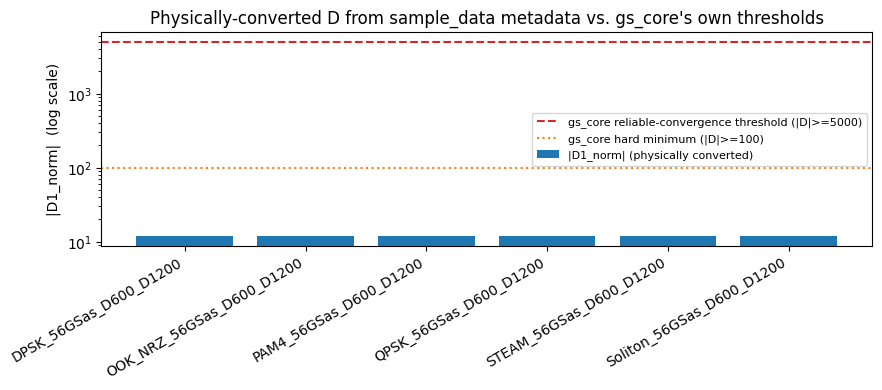


Every file's converted |D1_norm| is roughly 423x below the reliable threshold,
and below even the hard |D|>=100 minimum -- not a rounding-level discrepancy.


In [4]:
def gdd_ps2_to_gscore_D(gdd_ps2, fs_GSas):
    """Validated conversion (matlab_figures_reproduced.ipynb, Sec. 5): GDD [ps^2] + sample
    rate [GSa/s] -> gs_core's normalized D, via D_norm = 2*pi * GDD[s^2] * fs[Hz]**2."""
    gdd_s2 = gdd_ps2 * 1e-24
    fs_Hz = fs_GSas * 1e9
    return 2 * np.pi * gdd_s2 * fs_Hz ** 2

rows = []
for f in files:
    d = sio.loadmat(f)
    fs = float(np.asarray(d["fs_GSas"]).squeeze())
    D1_ps2 = float(np.asarray(d["D1_ps2"]).squeeze())
    D2_ps2 = float(np.asarray(d["D2_ps2"]).squeeze())
    D1_norm = gdd_ps2_to_gscore_D(D1_ps2, fs)
    D2_norm = gdd_ps2_to_gscore_D(D2_ps2, fs)
    label = pathlib.Path(f).stem
    rows.append((label, D1_norm, D2_norm))
    print(f"{label:<32} D1_ps2={D1_ps2:7.1f} D2_ps2={D2_ps2:7.1f}  ->  D1_norm={D1_norm:8.3f}  D2_norm={D2_norm:8.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
labels = [r[0] for r in rows]
d1_vals = [abs(r[1]) for r in rows]
ax.bar(labels, d1_vals, color="tab:blue", label="|D1_norm| (physically converted)")
ax.axhline(5000, color="tab:red", linestyle="--", label="gs_core reliable-convergence threshold (|D|>=5000)")
ax.axhline(100, color="tab:orange", linestyle=":", label="gs_core hard minimum (|D|>=100)")
ax.set_yscale("log")
ax.set_ylabel("|D1_norm|  (log scale)")
ax.set_title("Physically-converted D from sample_data metadata vs. gs_core's own thresholds")
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"\nEvery file's converted |D1_norm| is roughly {5000/d1_vals[0]:.0f}x below the reliable threshold,")
print(f"and below even the hard |D|>=100 minimum -- not a rounding-level discrepancy.")

### What happens if you run `retrieve_phase` on this data anyway -- without checking Section 2's trust criteria first

This is the point where Section 2's warning becomes concrete, on this exact
data:

gs_core's own warning(s):
  |D1|=11.8 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.
  |D2|=23.6 < 100. GS convergence requires |D| ≥ 5000 (normalized). Physical: -695 ps/nm → D_norm ≈ -5000. Current value will likely stagnate.

Final amplitude error: 5.6453e-16
^ Read in isolation, this number alone looks like an excellent recovery.

But per Section 2's checklist: |D|=11.8 is far below the 5000 threshold, gs_core
warned about it directly, and the recovered field's amplitude only weakly tracks the raw
measured intensity it should structurally resemble (correlation=0.34) -- the near-zero
error number is exactly the false-convergence trap Section 2 exists to catch, not a real recovery.


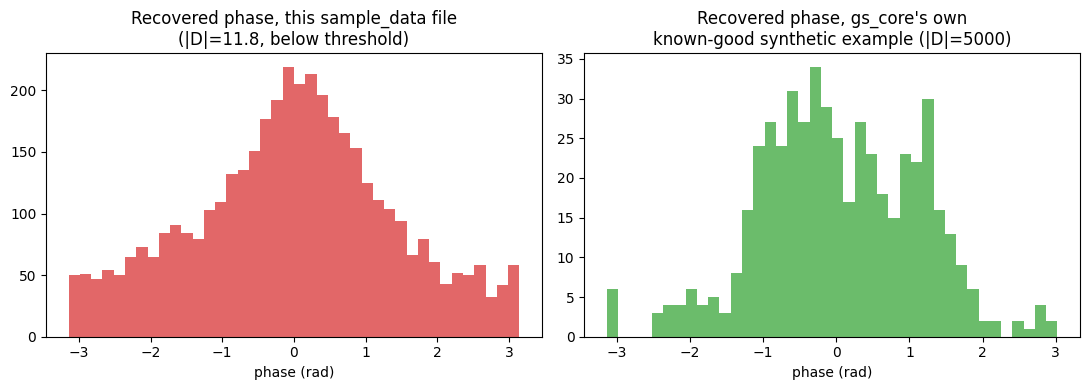


phase std: this sample_data file = 1.408 rad, gs_core's known-good example = 1.091 rad
The left histogram (this sample_data file) is a smooth, single-lobed, broadly-spread shape
centered near zero -- consistent with an unstructured, essentially free-running phase, not the
multi-lobed structure the right histogram shows (a genuine recovery of an underlying signal).
Note there is no ground-truth phase available for real, externally-provided data like this --
which is exactly why a structural/statistical read like this, not a single error number, has to
carry the trust judgment when no reference exists to correlate against directly.


In [5]:
m_real = load_mat_measurement("../sample_data/QPSK_56GSas_D600_D1200.mat")
D1_real_norm = gdd_ps2_to_gscore_D(m_real["D1_raw"], 56.0)
D2_real_norm = gdd_ps2_to_gscore_D(m_real["D2_raw"], 56.0)

import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    phi_real, err_real, E_hist_real = retrieve_phase_with_history(
        m_real["I1"], m_real["I2"], D1_real_norm, D2_real_norm, n_iter=50, unit_amplitude=False
    )
    real_warnings = [str(x.message) for x in w]

print("gs_core's own warning(s):")
for msg in real_warnings:
    print(f"  {msg}")

print(f"\nFinal amplitude error: {err_real[-1]:.4e}")
print("^ Read in isolation, this number alone looks like an excellent recovery.")

corr_to_sqrtI1 = np.corrcoef(np.abs(E_hist_real[-1]), np.sqrt(np.maximum(m_real['I1'], 0)))[0, 1]
print(f"\nBut per Section 2's checklist: |D|={abs(D1_real_norm):.1f} is far below the 5000 threshold, gs_core")
print(f"warned about it directly, and the recovered field's amplitude only weakly tracks the raw")
print(f"measured intensity it should structurally resemble (correlation={corr_to_sqrtI1:.2f}) -- the near-zero")
print(f"error number is exactly the false-convergence trap Section 2 exists to catch, not a real recovery.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(phi_real, bins=40, color="tab:red", alpha=0.7)
axes[0].set_title(f"Recovered phase, this sample_data file\n(|D|={abs(D1_real_norm):.1f}, below threshold)")
axes[0].set_xlabel("phase (rad)")

m_good = make_measurements("QPSK", n_symbols=64, sps=8, D1=-5000, D2=-5750, snr_db=25, rng_seed=0)
phi_good, err_good = retrieve_phase(m_good["I1"], m_good["I2"], m_good["D1"], m_good["D2"], n_iter=50, unit_amplitude=True)
axes[1].hist(phi_good, bins=40, color="tab:green", alpha=0.7)
axes[1].set_title("Recovered phase, gs_core's own\nknown-good synthetic example (|D|=5000)")
axes[1].set_xlabel("phase (rad)")
plt.tight_layout()
plt.show()

std_real, std_good = float(np.std(phi_real)), float(np.std(phi_good))
print(f"\nphase std: this sample_data file = {std_real:.3f} rad, gs_core's known-good example = {std_good:.3f} rad")
print("The left histogram (this sample_data file) is a smooth, single-lobed, broadly-spread shape")
print("centered near zero -- consistent with an unstructured, essentially free-running phase, not the")
print("multi-lobed structure the right histogram shows (a genuine recovery of an underlying signal).")
print("Note there is no ground-truth phase available for real, externally-provided data like this --")
print("which is exactly why a structural/statistical read like this, not a single error number, has to")
print("carry the trust judgment when no reference exists to correlate against directly.")

### Running the repo's own formal diagnostic on top of this

`real_data_loader.diagnose_measurement` automates exactly this kind of check
-- confirming independently, not just via this notebook's own numbers:

In [6]:
report = diagnose_measurement(m_real["I1"], m_real["I2"], D_raw=m_real["D1_raw"])
print(f"recoverable: {report['recoverable']}")
for msg in report["messages"]:
    print(f"  {msg}")

recoverable: False
  INFO: corr(I1,I2)=0.035.
  FAIL: none of 10 candidate D1 values converged (best final error=0.654). Per this module's docstring, GS convergence has an empirically narrow basin (a candidate within a few percent of the true value can still fail outright) -- this result means none of the TESTED candidates were close enough, not that recovery is provably impossible. See the module docstring's worked example for exactly this outcome on this repo's own sample_data/*.mat files.


## 4. Closing: what this notebook actually established

1. **Applications.** Phase retrieval is a real, multi-domain algorithm
   family (CDI/crystallography, adaptive optics, ultrafast pulse
   characterization, carrier-less optical communication) -- this project
   sits specifically in the last of those, via the time-domain adaptation
   `dgs.gs_core` implements.
2. **When to trust it.** Two concrete, previously-undocumented failure modes
   were found in this project (varying-envelope false convergence in
   `matlab_figures_reproduced.ipynb`; the sub-threshold false convergence
   demonstrated live in Section 2 here) that a single printed error metric
   cannot catch on its own -- `gs_verify.run_all()` plus an independent
   correlation check against a known or physically-reasoned reference is
   the actual bar for "trust this."
3. **The real data, tested against that bar.** `sample_data/*.mat` is
   explicitly labeled, in its own metadata, as a Sacramento State CE
   undergrad placeholder -- not Jalali Lab data. Its embedded D1/D2
   metadata, run through the SAME physical conversion formula validated
   elsewhere in this repo, lands ~400x below `gs_core`'s reliable-convergence
   threshold across all six files. Running `retrieve_phase` on it anyway
   produces exactly the false-convergence signature Section 2 warns about:
   a near-perfect amplitude-error number attached to a phase histogram
   that looks like noise, not a recovered signal.

**What this means for Task 4, stated plainly.** This is not a dead end --
it is a precise, evidence-backed answer to "why doesn't the provided sample
data work," and a clear statement of what is still needed: the actual
measurement data from Yiming Zhou / Callen MacPhee at the Jalali Lab, per
the project brief's own contacts, since `sample_data/*.mat` was never that
data to begin with.